In [3]:
# Importing Pandas for data manipulation and analysis (tables, CSV files, etc.)
import pandas as pd

# Importing NumPy for numerical operations and array handling
import numpy as np

# Importing Matplotlib for basic data visualization (plots, graphs)
import matplotlib.pyplot as plt

# Importing Seaborn for advanced and attractive statistical visualizations
import seaborn as sns

# Importing function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Importing LabelEncoder to convert categorical data into numerical form
# Importing StandardScaler to normalize/standardize numerical features
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Importing evaluation metrics to measure model performance
from sklearn.metrics import classification_report, accuracy_score

# Importing SimpleImputer to handle missing values in the dataset
from sklearn.impute import SimpleImputer

# Importing Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Importing Random Forest Classifier model
from sklearn.ensemble import RandomForestClassifier

# Importing XGBoost Classifier for advanced and high-performance modeling
from xgboost import XGBClassifier

# Importing warnings library to suppress unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")


In [4]:
#1. Load data
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv")


In [5]:
# Displaying the first 5 rows of the dataset to understand its structure and contents
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,2021 Apr 11 12:00:00 AM,2020 Nov 07 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020 Oct 21 12:00:00 AM,2020 Oct 18 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024 Dec 10 12:00:00 AM,2020 Oct 30 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,2020 Dec 24 12:00:00 AM,2020 Dec 24 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,2020 Oct 03 12:00:00 AM,2020 Sep 29 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [6]:
#duplicate values count 
df.duplicated().sum()  

0

In [7]:
df.shape

(1004991, 28)

In [8]:
#EDA Start

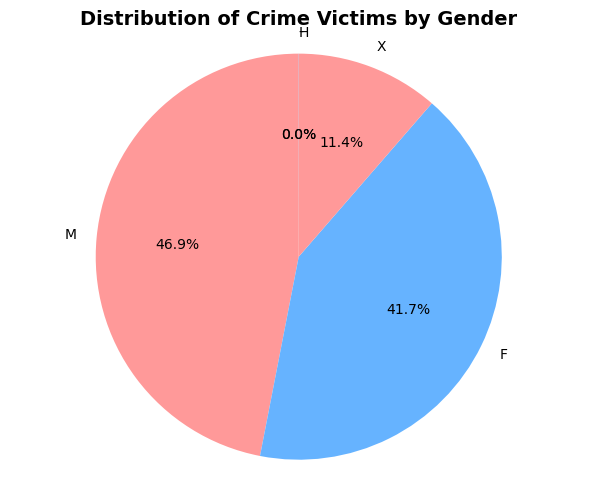

In [9]:
# Figure 1: Crime Distribution by Gender (Target Variable)
plt.figure(figsize=(12, 5))

# Subplot 1: Pie Chart
plt.subplot(1, 2, 1)
gender_counts = df['Vict Sex'].value_counts()
colors = ['#ff9999', '#66b3ff']
plt.pie(gender_counts, labels=gender_counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Crime Victims by Gender', fontsize=14, fontweight='bold')
plt.axis('equal')


plt.tight_layout()
plt.savefig('victim_gender_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

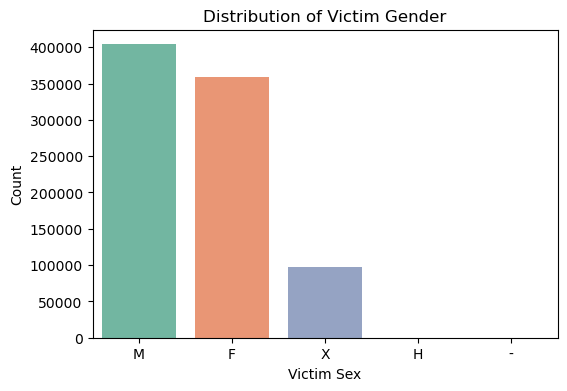

In [10]:
#Diagram: Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Vict Sex', data=df, palette='Set2')
plt.title('Distribution of Victim Gender')
plt.xlabel('Victim Sex')
plt.ylabel('Count')
plt.show()

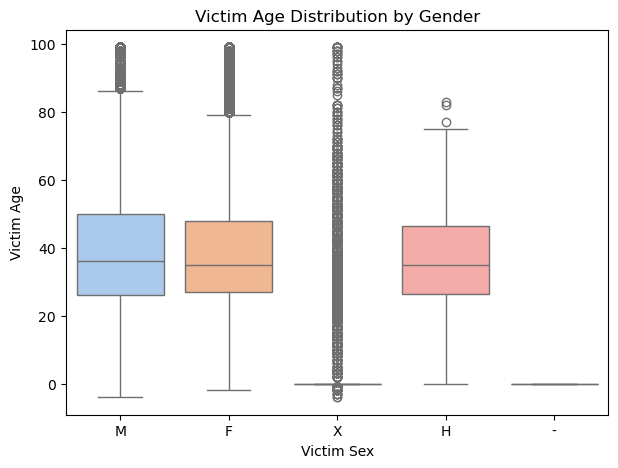

In [11]:
# 2. Victim Age Distribution – Box Plot (Very Strong)
plt.figure(figsize=(7,5))
sns.boxplot(x='Vict Sex', y='Vict Age', data=df, palette='pastel')
plt.title('Victim Age Distribution by Gender')
plt.xlabel('Victim Sex')
plt.ylabel('Victim Age')
plt.show()


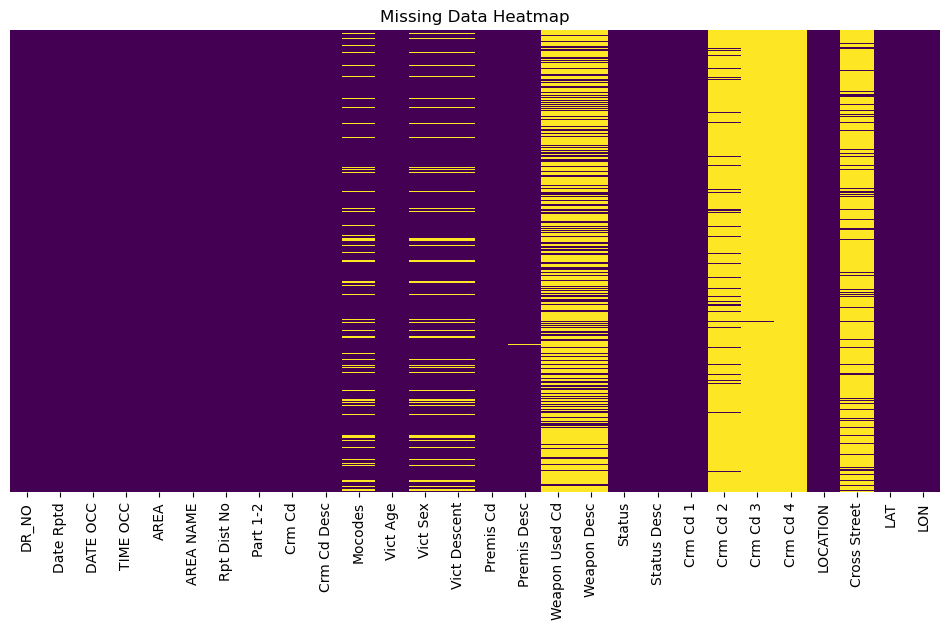

In [12]:
# Missing values heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

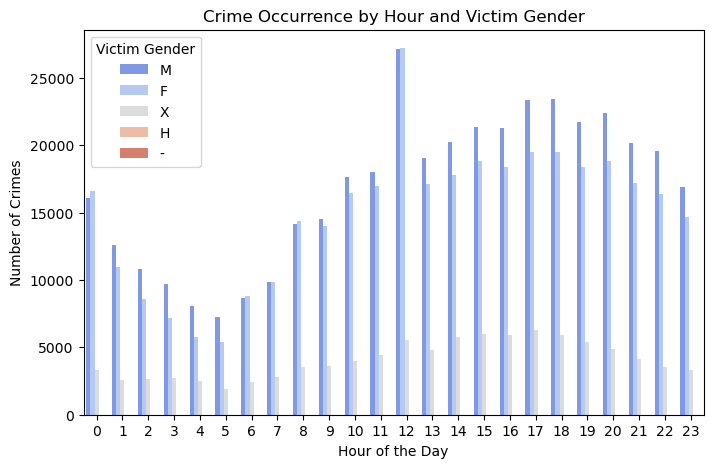

In [13]:
plt.figure(figsize=(8,5))

# Extract hour from TIME OCC (first 2 digits or divide by 100)
df['Hour'] = df['TIME OCC'] // 100  # Integer division to get hour

sns.countplot(x='Hour', hue='Vict Sex', data=df, palette='coolwarm')
plt.title('Crime Occurrence by Hour and Victim Gender')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Crimes')
plt.legend(title='Victim Gender')
plt.show()

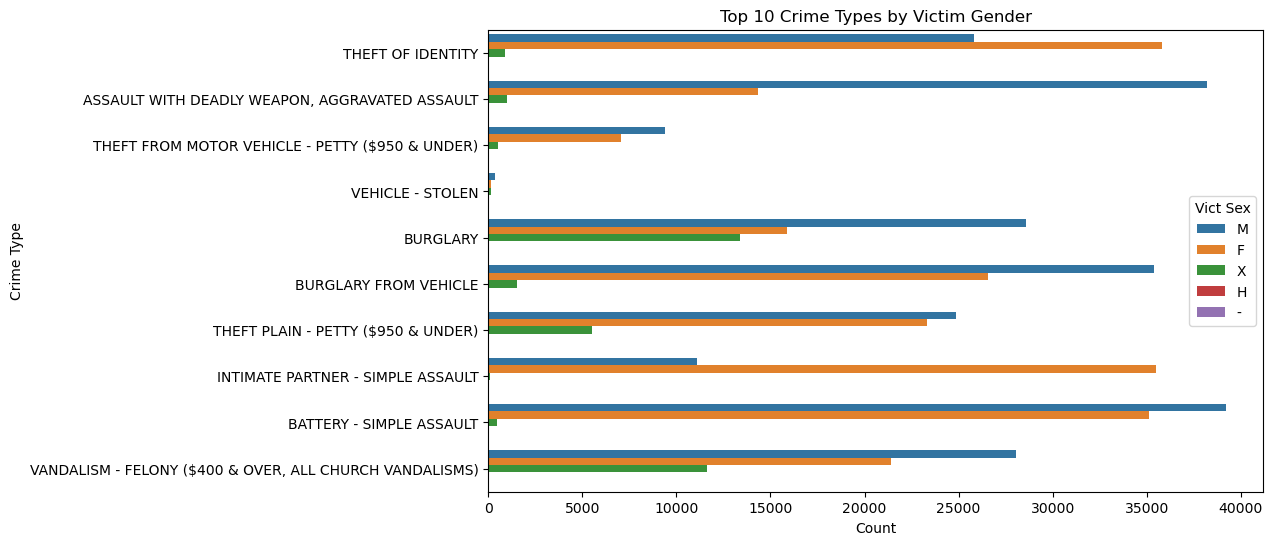

In [14]:
# 4. Crime Type vs Victim Gender – Top Categories 
top_crimes = df['Crm Cd Desc'].value_counts().head(10).index
filtered = df[df['Crm Cd Desc'].isin(top_crimes)]

plt.figure(figsize=(10,6))
sns.countplot(y='Crm Cd Desc', hue='Vict Sex', data=filtered)
plt.title('Top 10 Crime Types by Victim Gender')
plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.show()

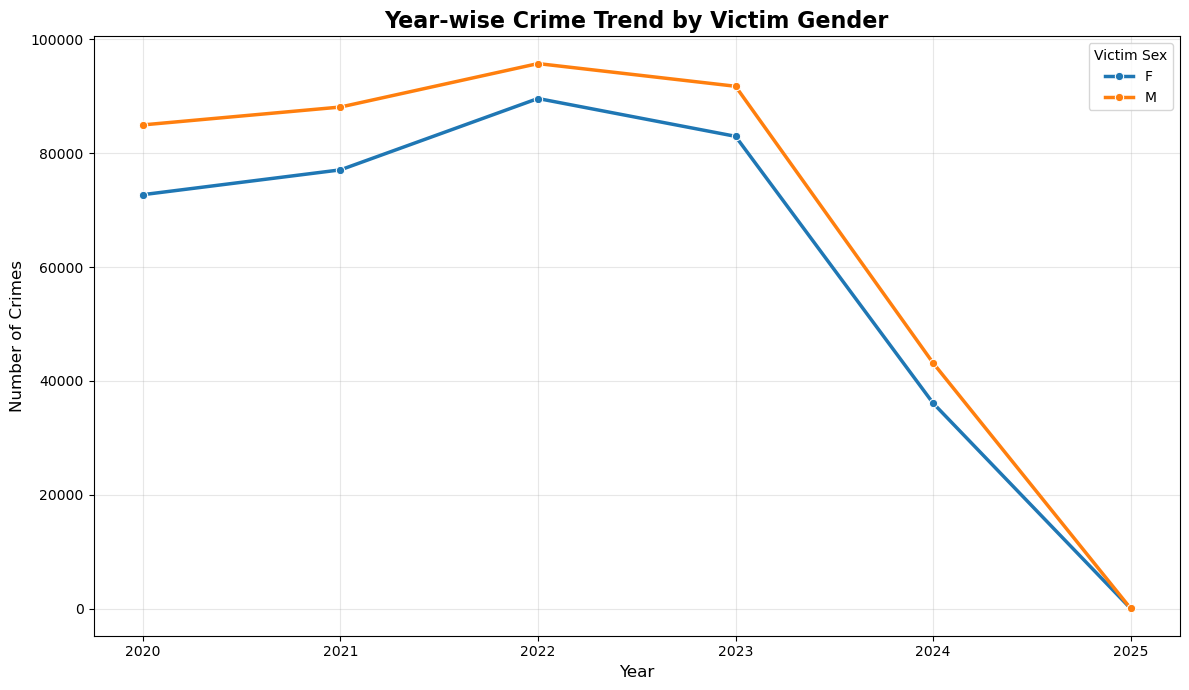

In [15]:
# Converting the 'DATE OCC' column to datetime format
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")

# Extracting year from the date
df["Year"] = df["DATE OCC"].dt.year

# Filtering valid genders and grouping data by year and victim sex
yearly_crime = (
    df[df["Vict Sex"].isin(["M", "F"])]
    .groupby(["Year", "Vict Sex"])
    .size()
    .reset_index(name="Crime Count")
)

# Setting the figure size for better visualization
plt.figure(figsize=(12, 7))

# Creating a line plot to show crime trends by gender over the years
sns.lineplot(
    data=yearly_crime,
    x="Year",
    y="Crime Count",
    hue="Vict Sex",
    marker="o",
    linewidth=2.5
)

# Adding title and labels
plt.title("Year-wise Crime Trend by Victim Gender", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)

# Customizing legend and grid
plt.legend(title="Victim Sex")
plt.grid(alpha=0.3)

# Adjusting layout, saving the plot, and displaying it
plt.tight_layout()
plt.savefig("yearwise_crime_trend_by_gender.png", dpi=300)
plt.show()


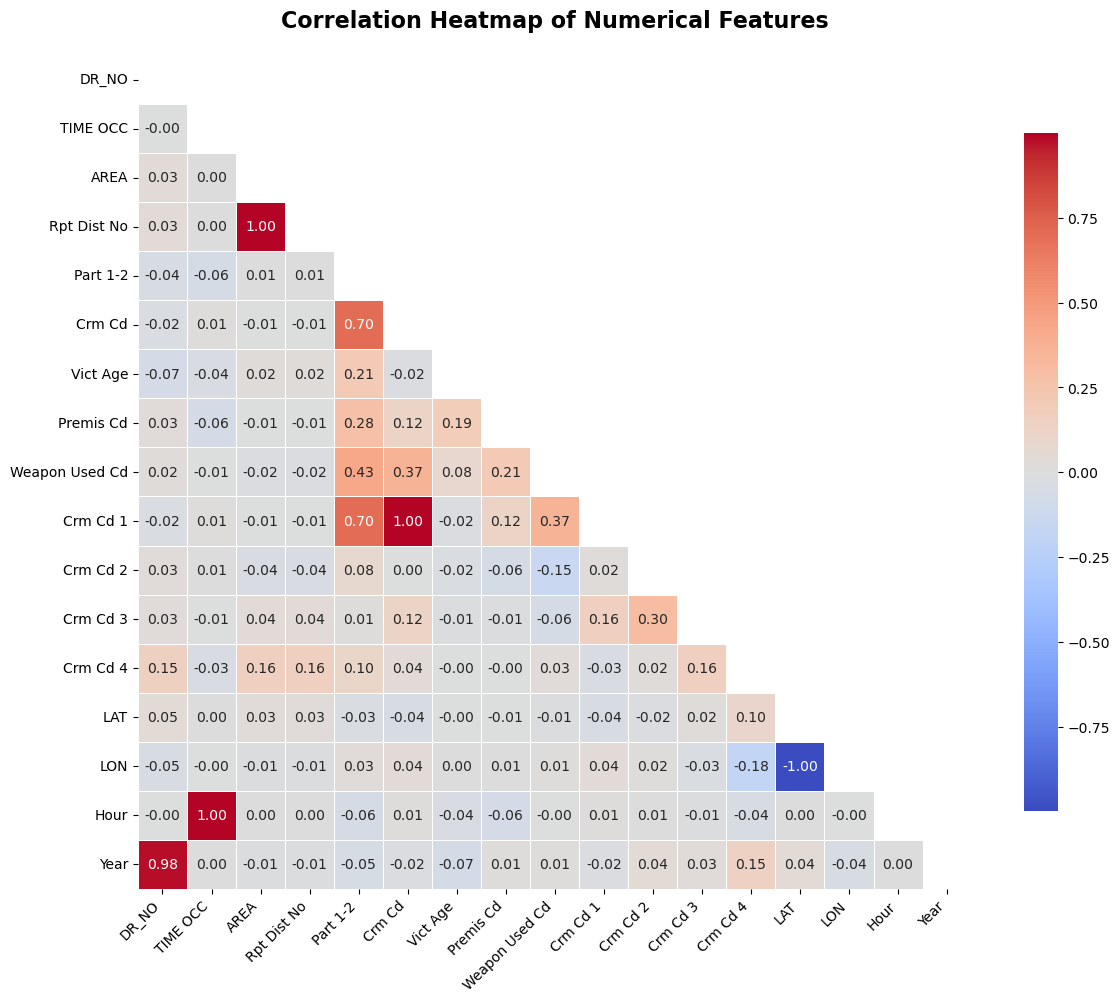

In [16]:
# Figure 5: Correlation Heatmap (Shows feature relationships)
plt.figure(figsize=(12, 10))

# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

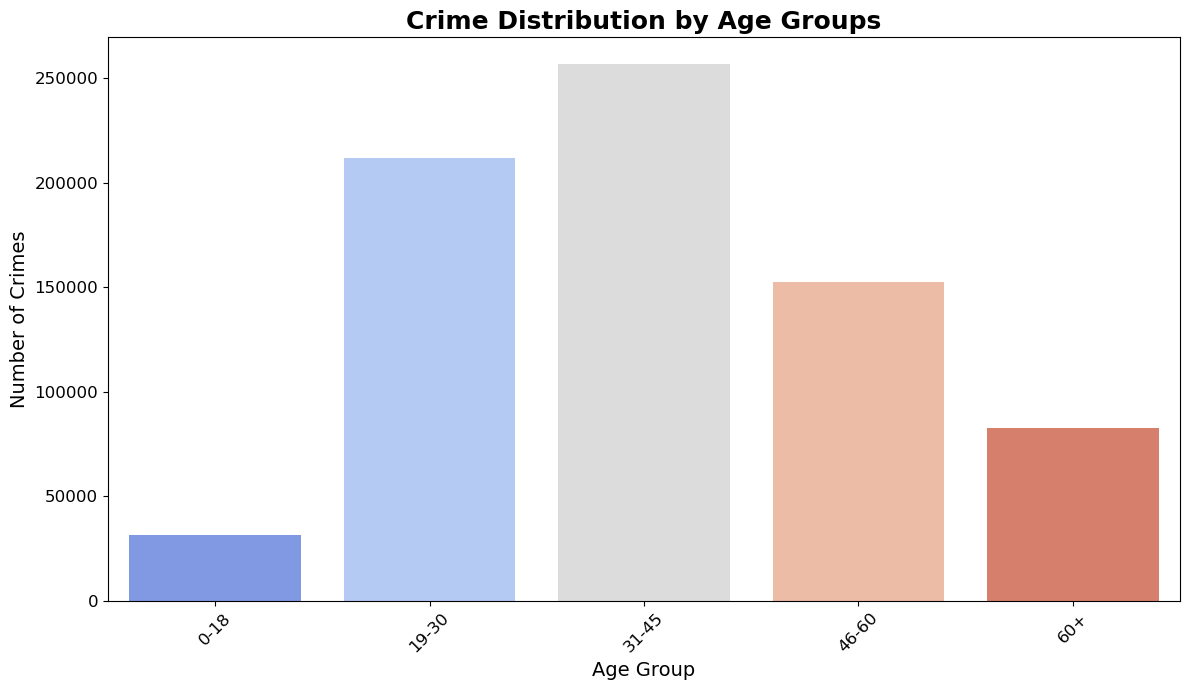

In [17]:
# Creating a large figure for better readability
plt.figure(figsize=(12, 7))

# Categorizing victim ages into defined age groups
df['Age_Group'] = pd.cut(
    df['Vict Age'], 
    bins=[0, 18, 30, 45, 60, 100], 
    labels=['0-18', '19-30', '31-45', '46-60', '60+']
)

# Counting the number of crimes in each age group
age_group_counts = df['Age_Group'].value_counts().sort_index()

# Creating a bar plot to show crime distribution by age groups
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='coolwarm')

# Adding title and axis labels
plt.title('Crime Distribution by Age Groups', fontsize=18, fontweight='bold')
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Number of Crimes', fontsize=14)

# Formatting tick labels
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Adjusting layout and displaying the plot
plt.tight_layout()
plt.show()


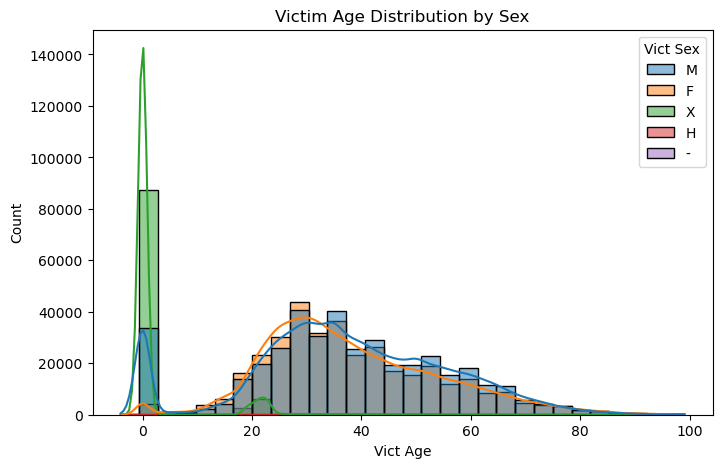

In [18]:
# Victim Age distribution by Sex
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Vict Age', hue='Vict Sex', bins=30, kde=True)
plt.title("Victim Age Distribution by Sex")
plt.show()

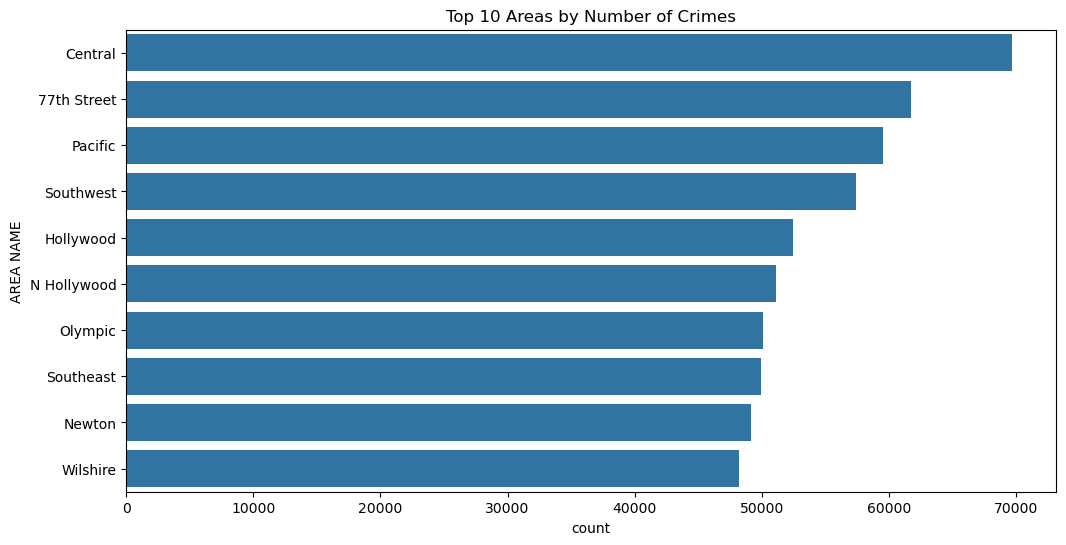

In [19]:
# Example of crime count by area name
plt.figure(figsize=(12,6))
top_areas = df['AREA NAME'].value_counts().nlargest(10).index
sns.countplot(data=df[df['AREA NAME'].isin(top_areas)], y='AREA NAME', order=top_areas)
plt.title("Top 10 Areas by Number of Crimes")
plt.show()

In [20]:
#EDA End

In [21]:
#Feature Engineering 

In [22]:
# Keep only valid binary classes
# First handle NaN values and strip whitespace
df["Vict Sex"] = df["Vict Sex"].fillna("Unknown")
df["Vict Sex"] = df["Vict Sex"].astype(str).str.strip()

# Filter for only M and F
df = df[df["Vict Sex"].isin(["M", "F"])].copy()

# Check balance
print(df["Vict Sex"].value_counts())
print(f"\nTotal records after filtering: {len(df)}")

Vict Sex
M    403879
F    358580
Name: count, dtype: int64

Total records after filtering: 762459


In [23]:
# Selecting relevant features to be used as input variables
features = [
    'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
    'Rpt Dist No', 'Part 1-2',
    'Premis Cd', 'Premis Desc',
    'Crm Cd', 'Crm Cd Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4',
    'Vict Age', 'Vict Descent',
    'Weapon Used Cd', 'Weapon Desc',
    'Status', 'Status Desc',
    'LAT', 'LON',
    'Cross Street', 'Mocodes', 'LOCATION'
]

# Creating feature matrix (X) and target variable (y)
X = df[features].copy()
y = df["Vict Sex"].copy()


In [24]:
# . Feature engineering
# Convert 'DATE OCC' to datetime and extract year, month, day
X['DATE OCC'] = pd.to_datetime(X['DATE OCC'], errors='coerce')
X['Year'] = X['DATE OCC'].dt.year
X['Month'] = X['DATE OCC'].dt.month
X['Day'] = X['DATE OCC'].dt.day

# Extract hour and minute from 'TIME OCC' (stored as HHMM)
X['Hour'] = X['TIME OCC'] // 100
X['Minute'] = X['TIME OCC'] % 100

# Drop original date and time columns as they are now encoded
X.drop(columns=['DATE OCC', 'TIME OCC'], inplace=True)


In [25]:
# 5. Handle missing values

# Categorical columns - fill missing with 'Unknown'
cat_cols = [
    'AREA NAME', 'Premis Desc', 'Crm Cd Desc', 'Vict Descent', 
    'Weapon Desc', 'Status', 'Status Desc',
    'Cross Street', 'Mocodes', 'LOCATION'
]
for col in cat_cols:
    X[col] = X[col].fillna('Unknown')

In [26]:
# Numeric columns with missing values filled with -1 (sparse codes)
num_cols_fill_minus_one = ['Weapon Used Cd', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']
for col in num_cols_fill_minus_one:
    X[col] = X[col].fillna(-1)

In [27]:

# Other numeric columns: median imputation
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [col for col in num_cols if col not in num_cols_fill_minus_one]

In [28]:
# Handling missing values
from sklearn.impute import SimpleImputer

# Create an imputer to fill missing values in numerical columns using median
imputer = SimpleImputer(strategy='median')

# Apply the imputer to the numerical columns
X[num_cols] = imputer.fit_transform(X[num_cols])

In [29]:
# . Encode categorical features
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


In [30]:
# . Encode target
y = LabelEncoder().fit_transform(y)

In [31]:
# . Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
# . Feature scaling (ONLY ONCE)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test = scaler.transform(X_test)  # Transform test using train parameters

In [33]:
# Convert to DataFrame if needed
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [34]:
# Check NaN
print("NaN count in train:\n", X_train_df.isna().sum().sum())
print("NaN count in test:\n", X_test_df.isna().sum().sum())

NaN count in train:
 0
NaN count in test:
 0


In [35]:
# Check infinity
print("Inf count in train:\n", np.isinf(X_train_df).sum().sum())
print("Inf count in test:\n", np.isinf(X_test_df).sum().sum())

Inf count in train:
 0
Inf count in test:
 0


In [36]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [37]:
pred_lr = model.predict(X_test)

In [38]:
pred_lr

array([1, 0, 0, ..., 1, 0, 0])

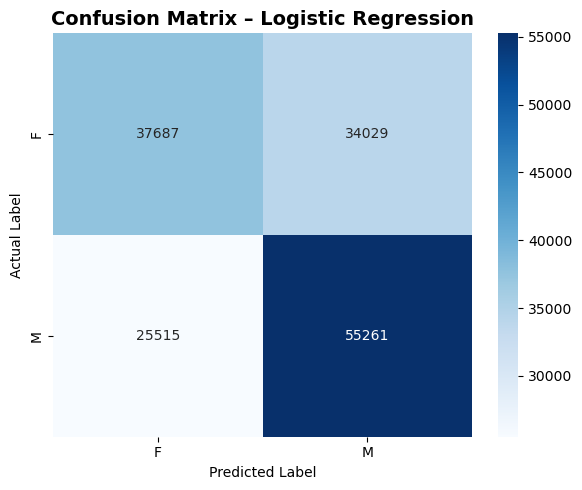

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["F", "M"],  
    yticklabels=["F", "M"]
)

plt.title("Confusion Matrix – Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


In [40]:
# Calculate and display the accuracy of the model on the test set
accuracy = accuracy_score(y_test, pred_lr)
print(f"Accuracy: {accuracy:.4f}")

# Display detailed classification metrics: precision, recall, F1-score
print("Classification Report:")
print(classification_report(y_test, pred_lr))


Accuracy: 0.6095
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.53      0.56     71716
           1       0.62      0.68      0.65     80776

    accuracy                           0.61    152492
   macro avg       0.61      0.60      0.60    152492
weighted avg       0.61      0.61      0.61    152492



In [41]:
#Feature Importance 

In [42]:
# Logistic Regression coefficients
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Initialize Logistic Regression model with higher max iterations
lr_model = LogisticRegression(max_iter=2000)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Create a DataFrame mapping each feature to its learned coefficient
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

# Display the coefficients to interpret the impact of each feature
print("\n=== LOGISTIC REGRESSION COEFFICIENTS ===")
print(coef_df)


=== LOGISTIC REGRESSION COEFFICIENTS ===
           Feature  Coefficient
18             LAT     1.623299
19             LON     1.619610
16          Status     0.475304
8         Crm Cd 1     0.304297
13    Vict Descent     0.207024
9         Crm Cd 2     0.061915
27          Minute     0.045253
0             AREA     0.044204
25             Day     0.028840
22        LOCATION     0.020343
1        AREA NAME     0.005117
11        Crm Cd 4     0.001367
26            Hour    -0.001553
24           Month    -0.007373
23            Year    -0.013973
20    Cross Street    -0.015920
10        Crm Cd 3    -0.022748
12        Vict Age    -0.042207
2      Rpt Dist No    -0.083542
5      Premis Desc    -0.102724
21         Mocodes    -0.107705
14  Weapon Used Cd    -0.138249
15     Weapon Desc    -0.142269
3         Part 1-2    -0.156374
7      Crm Cd Desc    -0.158623
4        Premis Cd    -0.184362
6           Crm Cd    -0.298292
17     Status Desc    -0.382689


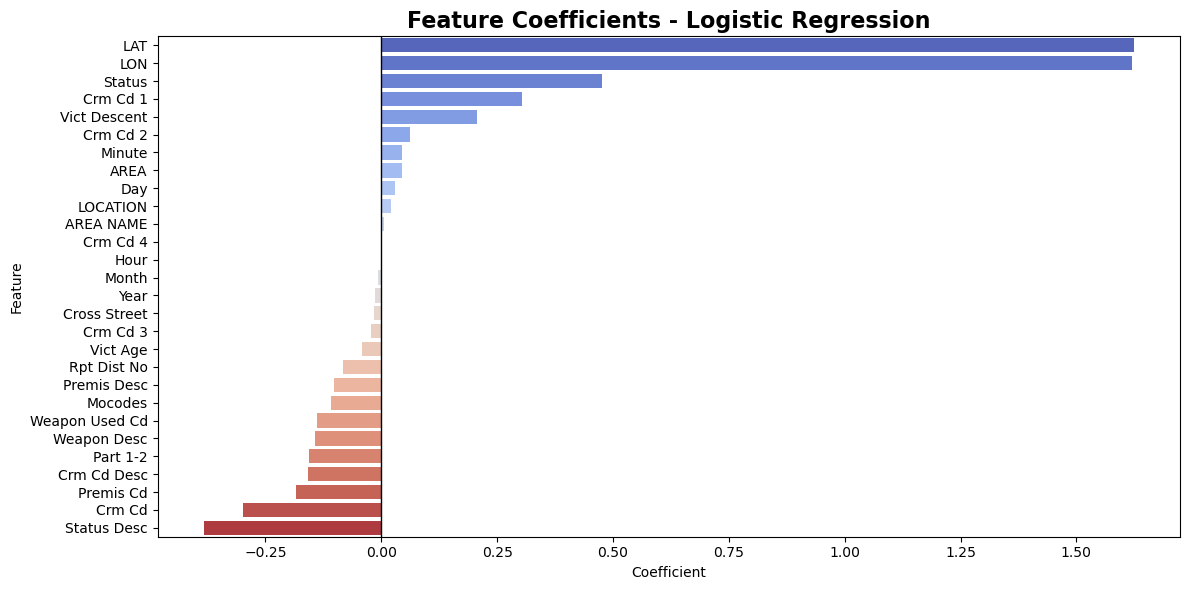

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coef_df,
    palette="coolwarm"
)

plt.title("Feature Coefficients - Logistic Regression", fontsize=16, fontweight="bold")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()


In [44]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [45]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [46]:
# Predict the target variable for the test set using the trained model
pred_rf = model.predict(X_test)

In [47]:
pred_rf

array([1, 1, 1, ..., 0, 0, 1])

In [49]:
accuracy_score(y_test, pred_rf)
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.66      0.58      0.62     71716
           1       0.66      0.73      0.70     80776

    accuracy                           0.66    152492
   macro avg       0.66      0.66      0.66    152492
weighted avg       0.66      0.66      0.66    152492



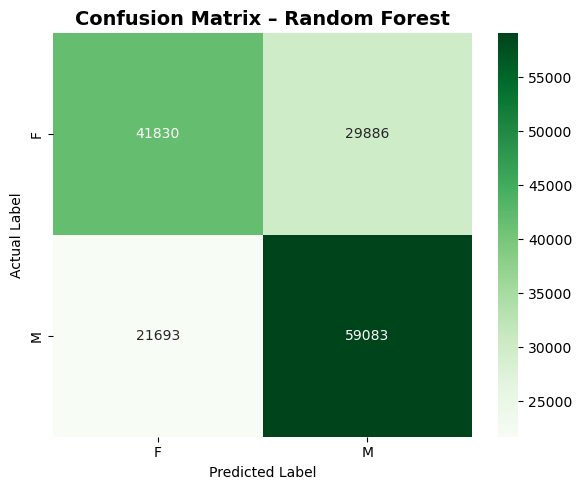

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix for Random Forest predictions
cm_rf = confusion_matrix(y_test, pred_rf)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,       # Show counts in each cell
    fmt="d",          # Integer format
    cmap="Greens",    # Color map
    xticklabels=["F", "M"],  # Predicted labels
    yticklabels=["F", "M"]   # Actual labels
)

# Add title and axis labels
plt.title("Confusion Matrix – Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Adjust layout and display plot
plt.tight_layout()
plt.show()

In [51]:
# Random Forest 
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(feature_importance_rf)


=== RANDOM FOREST FEATURE IMPORTANCE ===
           Feature  Importance
12        Vict Age    0.094619
21         Mocodes    0.078326
22        LOCATION    0.075337
18             LAT    0.074909
19             LON    0.073381
2      Rpt Dist No    0.064127
25             Day    0.063371
26            Hour    0.056956
24           Month    0.048687
27          Minute    0.041661
4        Premis Cd    0.040623
13    Vict Descent    0.031456
23            Year    0.030900
6           Crm Cd    0.029022
8         Crm Cd 1    0.028345
5      Premis Desc    0.027630
7      Crm Cd Desc    0.025436
1        AREA NAME    0.021986
0             AREA    0.020300
20    Cross Street    0.015676
15     Weapon Desc    0.015398
14  Weapon Used Cd    0.013365
3         Part 1-2    0.008710
16          Status    0.007280
17     Status Desc    0.007124
9         Crm Cd 2    0.005079
10        Crm Cd 3    0.000277
11        Crm Cd 4    0.000019


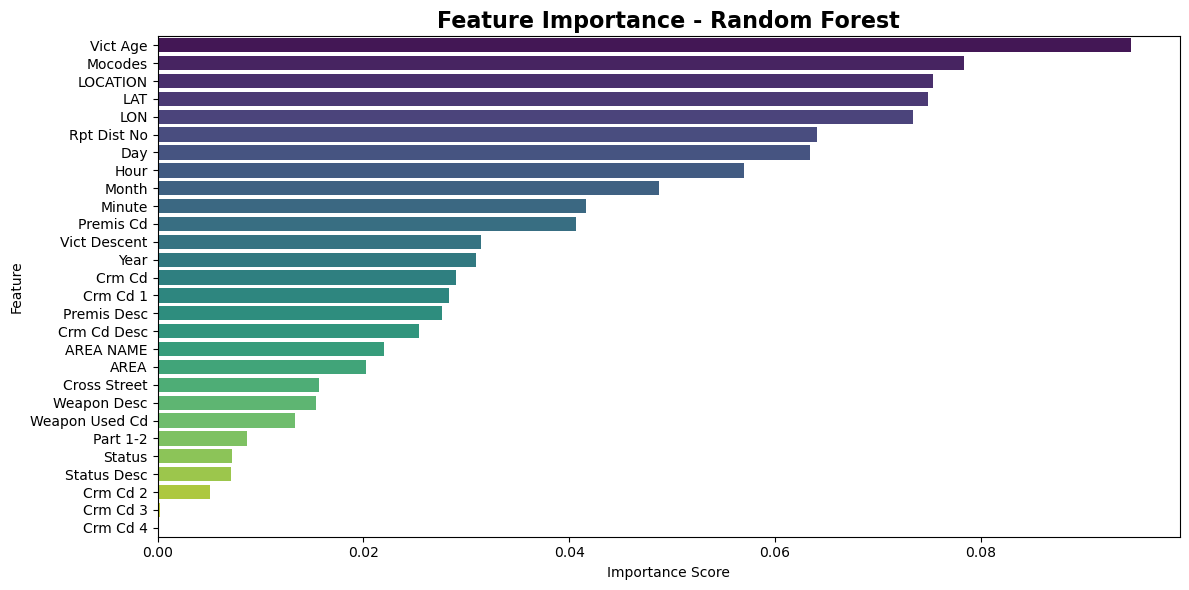

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size for readability
plt.figure(figsize=(12, 6))

# Create a horizontal bar plot showing feature importance scores
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_rf,
    palette="viridis"
)

# Add title and axis labels
plt.title("Feature Importance - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [53]:
#XGBOOST
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [54]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,eval_metric="logloss")
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [55]:
pred_xgb = model.predict(X_test)

In [56]:
pred_xgb

array([1, 1, 0, ..., 0, 0, 1])

In [57]:
accuracy_score(y_test, pred_xgb)
print(classification_report(y_test, pred_xgb))




              precision    recall  f1-score   support

           0       0.67      0.55      0.60     71716
           1       0.65      0.76      0.70     80776

    accuracy                           0.66    152492
   macro avg       0.66      0.65      0.65    152492
weighted avg       0.66      0.66      0.66    152492



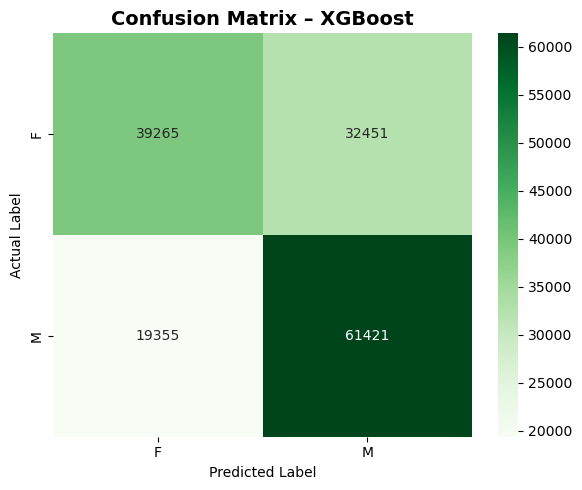

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix for XGBoost predictions
cm_xgb = confusion_matrix(y_test, pred_xgb)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,       # Display counts in each cell
    fmt="d",          # Format as integers
    cmap="Greens",    # Color map
    xticklabels=["F", "M"],  # Predicted labels
    yticklabels=["F", "M"]   # Actual labels
)

# Add title and axis labels
plt.title("Confusion Matrix – XGBoost", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [59]:
# Feature importance values
feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== XGBOOST FEATURE IMPORTANCE ===")
print(feature_importance_xgb)



=== XGBOOST FEATURE IMPORTANCE ===
           Feature  Importance
3         Part 1-2    0.385183
12        Vict Age    0.068542
13    Vict Descent    0.058603
4        Premis Cd    0.053172
7      Crm Cd Desc    0.052803
6           Crm Cd    0.052192
15     Weapon Desc    0.050994
8         Crm Cd 1    0.050339
14  Weapon Used Cd    0.028477
21         Mocodes    0.019793
9         Crm Cd 2    0.019792
0             AREA    0.016088
18             LAT    0.015191
25             Day    0.015016
16          Status    0.014436
17     Status Desc    0.012328
5      Premis Desc    0.011583
2      Rpt Dist No    0.010852
19             LON    0.010014
1        AREA NAME    0.009550
26            Hour    0.008473
23            Year    0.007085
22        LOCATION    0.005377
11        Crm Cd 4    0.005354
27          Minute    0.005292
20    Cross Street    0.005180
10        Crm Cd 3    0.004248
24           Month    0.004043


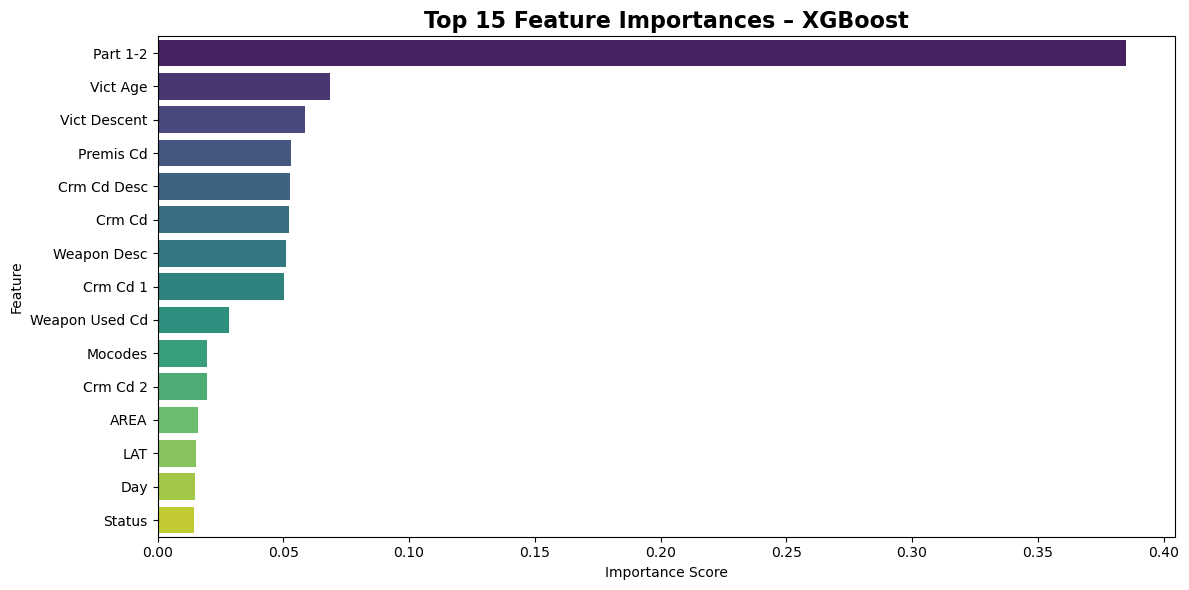

In [60]:
# Plot XGBoost Feature Importance
plt.figure(figsize=(12, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_xgb.head(15),  # Top 15 for clarity
    palette="viridis"
)

plt.title(
    "Top 15 Feature Importances – XGBoost",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [61]:
logistic_accuracy = accuracy_score(y_test, pred_lr)
rf_accuracy = accuracy_score(y_test, pred_rf)
xgb_accuracy = accuracy_score(y_test, pred_xgb)


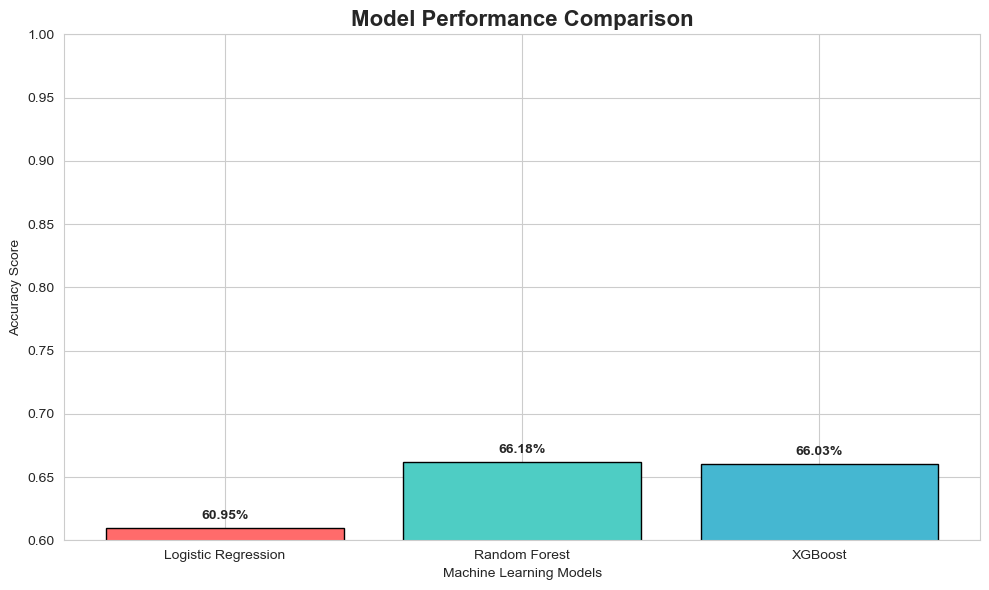

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy values
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [logistic_accuracy, rf_accuracy, xgb_accuracy]

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

bars = plt.bar(
    models,
    accuracies,
    color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
    edgecolor='black'
)

# Add value labels
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.005,
        f"{acc:.2%}",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy Score')
plt.ylim(0.6, 1.0)  # Clear academic range
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()


In [63]:
# MODEL EVALUATION
print("LOGISTIC REGRESSION")
print(classification_report(y_test, pred_lr))

print("RANDOM FOREST")
print(classification_report(y_test, pred_rf))

print("XGBOOST")
print(classification_report(y_test, pred_xgb))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.60      0.53      0.56     71716
           1       0.62      0.68      0.65     80776

    accuracy                           0.61    152492
   macro avg       0.61      0.60      0.60    152492
weighted avg       0.61      0.61      0.61    152492

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.66      0.58      0.62     71716
           1       0.66      0.73      0.70     80776

    accuracy                           0.66    152492
   macro avg       0.66      0.66      0.66    152492
weighted avg       0.66      0.66      0.66    152492

XGBOOST
              precision    recall  f1-score   support

           0       0.67      0.55      0.60     71716
           1       0.65      0.76      0.70     80776

    accuracy                           0.66    152492
   macro avg       0.66      0.65      0.65    152492
weighted avg       0.66      0.6

In [64]:

# HYPERPARAMETER TUNING + NEURAL NETWORK (NO NN TUNING)

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd


In [65]:

# 1. RANDOM FOREST – HYPERPARAMETER TUNING


# Use a stratified sample for faster tuning
rng = np.random.RandomState(42)
sample_size = min(120000, X_train.shape[0])
sample_idx = rng.choice(X_train.shape[0], size=sample_size, replace=False)

X_tune = X_train[sample_idx]
y_tune = y_train[sample_idx]

rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_tune, y_tune)

rf_best = rf_search.best_estimator_
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

pred_rf_tuned = rf_best.predict(X_test)

print("\nRANDOM FOREST (TUNED)")
print(classification_report(y_test, pred_rf_tuned))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

RANDOM FOREST (TUNED)
              precision    recall  f1-score   support

           0       0.66      0.50      0.57     71716
           1       0.64      0.77      0.70     80776

    accuracy                           0.65    152492
   macro avg       0.65      0.64      0.64    152492
weighted avg       0.65      0.65      0.64    152492



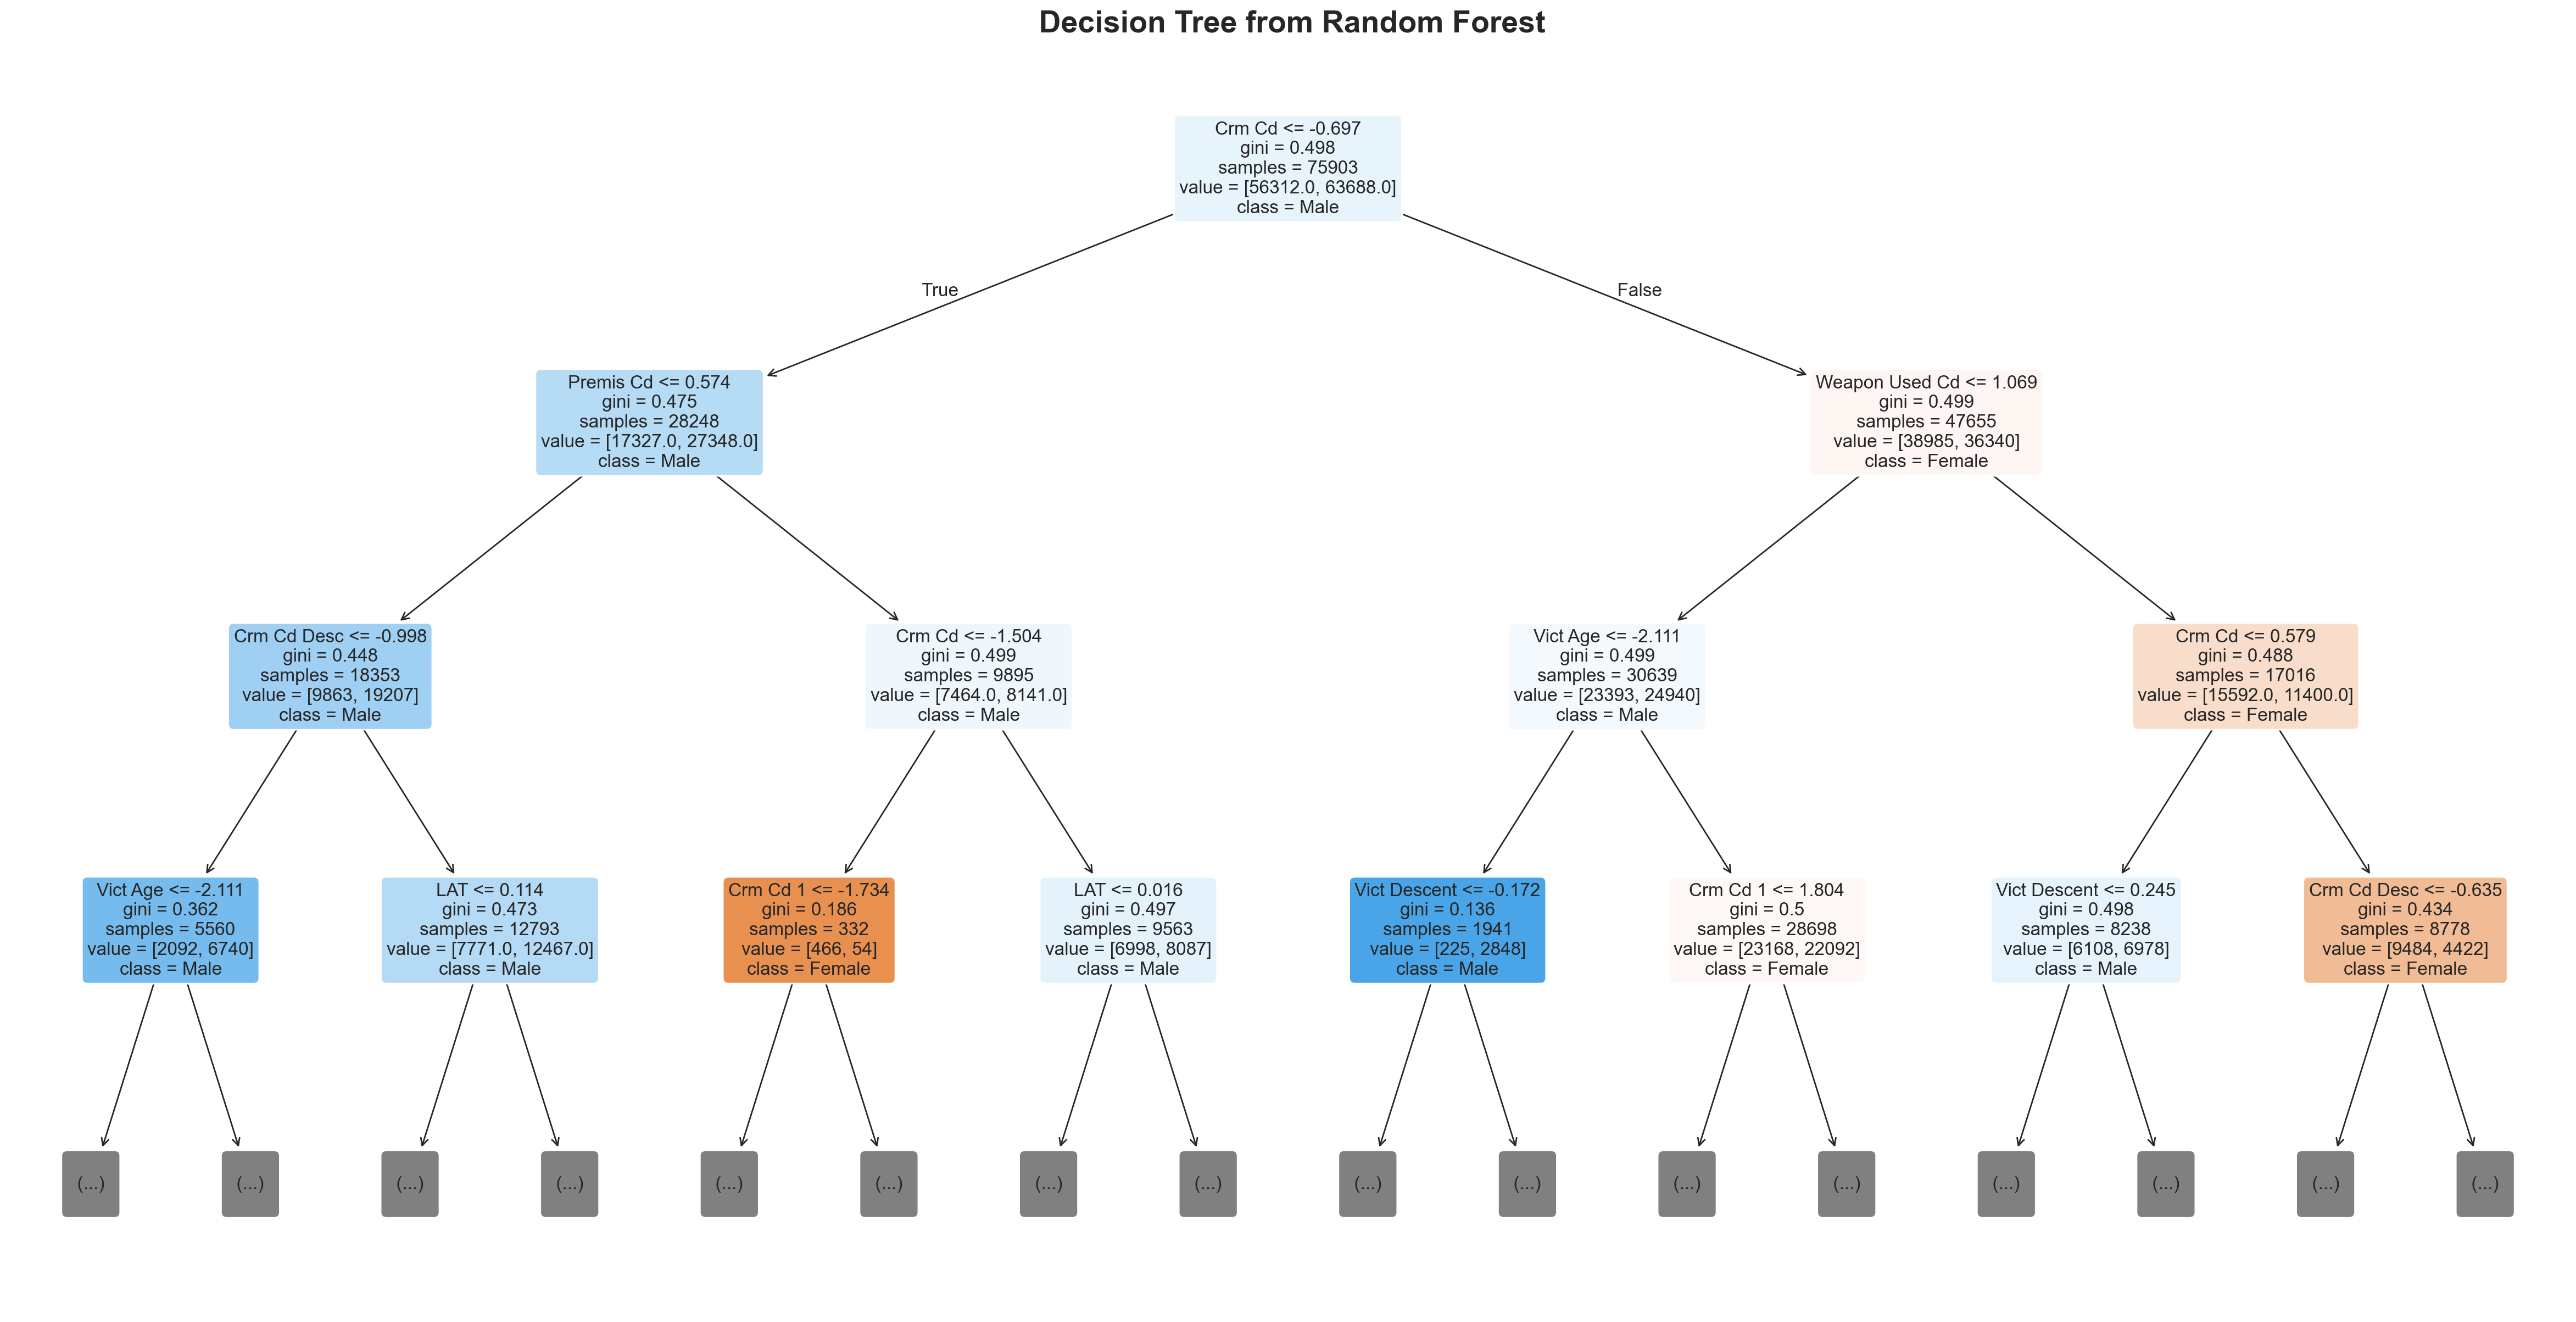

In [66]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15), dpi=200)   

plot_tree(
    rf_best.estimators_[0],              # or rf_model.estimators_[0]
    feature_names=X.columns,
    class_names=["Female", "Male"],
    filled=True,
    rounded=True,
    max_depth=3,                         # VERY IMPORTANT
    fontsize=12
)

plt.title(" Decision Tree from Random Forest", fontsize=20, fontweight="bold")
plt.show()


In [67]:

# 2. XGBOOST – HYPERPARAMETER TUNING

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# Define the parameter grid for tuning XGBoost
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 1.0],
    "reg_lambda": [1.0, 1.5, 2.0]
}

# Initialize base XGBoost classifier
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",  # Evaluation metric for classification
    n_jobs=-1               # Use all CPU cores
)

# Perform Randomized Search for hyperparameter tuning
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=15,              # Number of random parameter combinations
    scoring="f1",           # Optimization metric
    cv=cv,                  # Cross-validation folds
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV on the tuning dataset
xgb_search.fit(X_tune, y_tune)

# Retrieve the best estimator after tuning
xgb_best = xgb_search.best_estimator_

# Display the best hyperparameters
print(" Best XGBoost Parameters:")
print(xgb_search.best_params_)

# Make predictions on the test set using the tuned model
pred_xgb_tuned = xgb_best.predict(X_test)

# Evaluate the tuned XGBoost model
print("\nXGBOOST (TUNED)")
print(classification_report(y_test, pred_xgb_tuned))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
 Best XGBoost Parameters:
{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

XGBOOST (TUNED)
              precision    recall  f1-score   support

           0       0.66      0.53      0.59     71716
           1       0.65      0.76      0.70     80776

    accuracy                           0.65    152492
   macro avg       0.66      0.65      0.65    152492
weighted avg       0.65      0.65      0.65    152492



In [68]:


# 3. NEURAL NETWORK (FEEDFORWARD MLP – NO TUNING)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    n_iter_no_change=5,
    random_state=42
)

mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

print("\nNEURAL NETWORK (MLP)")
print(classification_report(y_test, pred_mlp))





NEURAL NETWORK (MLP)
              precision    recall  f1-score   support

           0       0.65      0.53      0.58     71716
           1       0.64      0.75      0.69     80776

    accuracy                           0.65    152492
   macro avg       0.65      0.64      0.64    152492
weighted avg       0.65      0.65      0.64    152492



In [69]:

# 4. FINAL MODEL COMPARISON TABLE


def metrics_row(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

results = []
results.append(metrics_row("Logistic Regression", y_test, pred_lr))
results.append(metrics_row("Random Forest (Default)", y_test, pred_rf))
results.append(metrics_row("XGBoost (Default)", y_test, pred_xgb))
results.append(metrics_row("Random Forest (Tuned)", y_test, pred_rf_tuned))
results.append(metrics_row("XGBoost (Tuned)", y_test, pred_xgb_tuned))
results.append(metrics_row("Neural Network (MLP)", y_test, pred_mlp))

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost (Default),0.660271,0.654306,0.760387,0.703369
4,XGBoost (Tuned),0.653490,0.647578,0.758790,0.698787
3,Random Forest (Tuned),0.646545,0.637062,0.773274,0.698590
1,Random Forest (Default),0.661759,0.664085,0.731443,0.696138
5,Neural Network (MLP),0.645254,0.641460,0.748873,0.691018
0,Logistic Regression,0.609527,0.618893,0.684126,0.649877


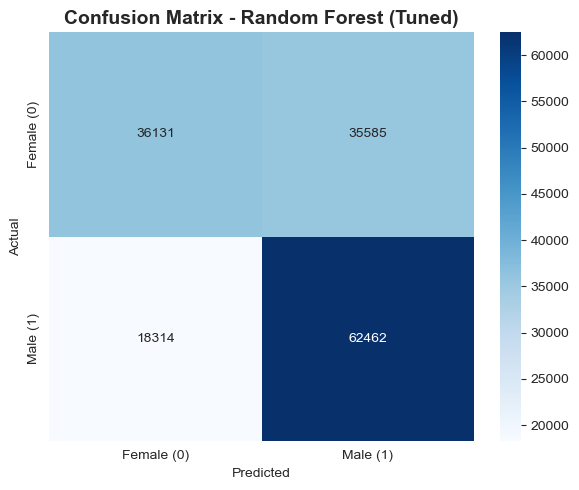

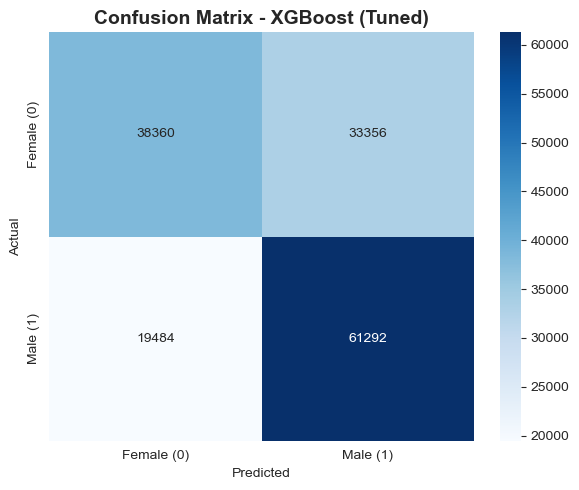

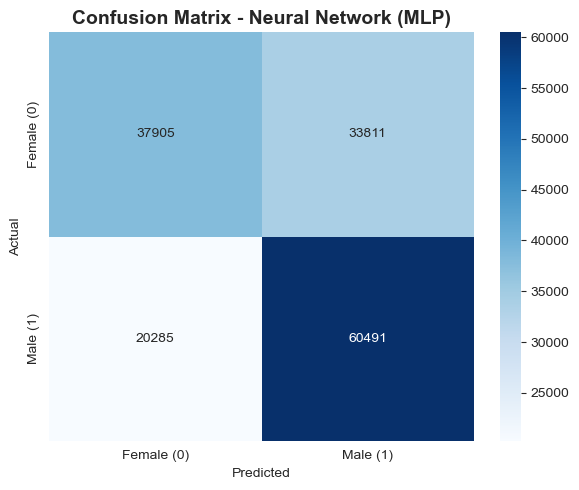

In [70]:

# CONFUSION MATRICES FOR TUNED MODELS (RF Tuned + XGB Tuned + MLP)


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_true, y_pred, title, labels=("Female (0)", "Male (1)")):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Tuned Random Forest
plot_cm(y_test, pred_rf_tuned, "Confusion Matrix - Random Forest (Tuned)")

# Tuned XGBoost
plot_cm(y_test, pred_xgb_tuned, "Confusion Matrix - XGBoost (Tuned)")

# Neural Network (MLP)
plot_cm(y_test, pred_mlp, "Confusion Matrix - Neural Network (MLP)")


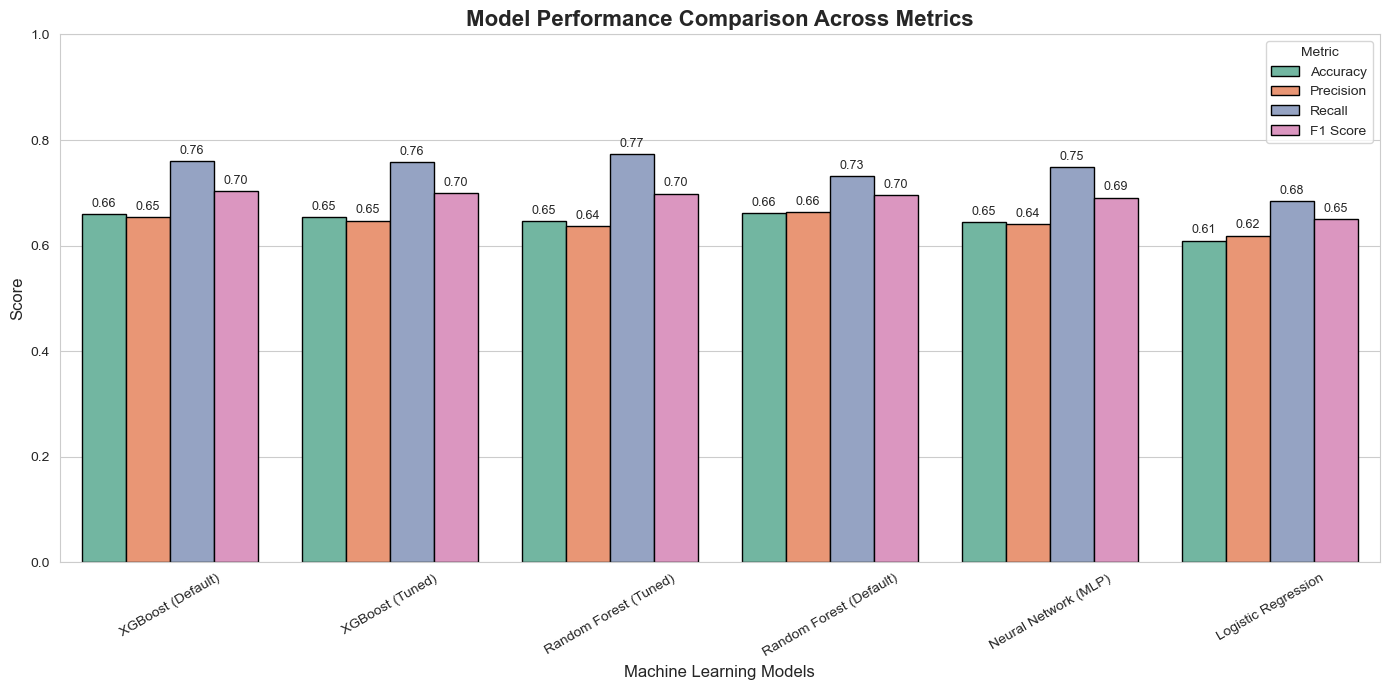

In [74]:
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=results_melted,
    palette="Set2",
    edgecolor="black"
)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.title("Model Performance Comparison Across Metrics", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Metric")

plt.tight_layout()
plt.savefig("model_comparison_all_metrics.png", dpi=300)
plt.show()


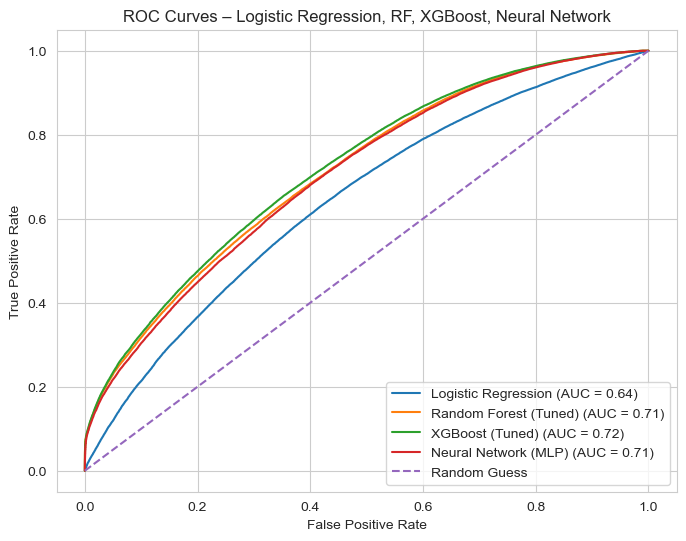

In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Dictionary of trained models
models = {
    "Logistic Regression": lr_model,
    "Random Forest (Tuned)": rf_best,
    "XGBoost (Tuned)": xgb_best,
    "Neural Network (MLP)": mlp
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    
    # Predicted probabilities for positive class
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    
    # Compute AUC
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random guessing baseline
plt.plot([0, 1], [0, 1], '--', label="Random Guess")

plt.title("ROC Curves – Logistic Regression, RF, XGBoost, Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [87]:
import pandas as pd
import numpy as np

# Predict victim gender for one unseen sample


def predict_victim_gender():
    # Create one row with all features used during training
    sample_df = pd.DataFrame(0, index=[0], columns=X.columns)

    # Filling with some realistic values for key features
    if "Vict Age" in sample_df.columns:
        sample_df.at[0, "Vict Age"] = 32

    if "Hour" in sample_df.columns:
        sample_df.at[0, "Hour"] = 21

    if "Minute" in sample_df.columns:
        sample_df.at[0, "Minute"] = 15

    if "Year" in sample_df.columns:
        sample_df.at[0, "Year"] = 2022

    if "Month" in sample_df.columns:
        sample_df.at[0, "Month"] = 7

    if "Day" in sample_df.columns:
        sample_df.at[0, "Day"] = 15

    if "AREA" in sample_df.columns:
        sample_df.at[0, "AREA"] = 6

    if "Crm Cd" in sample_df.columns:
        sample_df.at[0, "Crm Cd"] = 624

    if "Weapon Used Cd" in sample_df.columns:
        sample_df.at[0, "Weapon Used Cd"] = -1  # unknown weapon

    if "LAT" in sample_df.columns:
        sample_df.at[0, "LAT"] = 34.0522

    if "LON" in sample_df.columns:
        sample_df.at[0, "LON"] = -118.2437

    # Scale the sample using the same scaler as training
    sample_scaled = scaler.transform(sample_df)

    # Get predictions from all models
    predictions = {
        "Logistic Regression":
            "Male" if lr_model.predict(sample_scaled)[0] == 1 else "Female",

        "Random Forest (Tuned)":
            "Male" if rf_best.predict(sample_scaled)[0] == 1 else "Female",

        "XGBoost (Tuned)":
            "Male" if xgb_best.predict(sample_scaled)[0] == 1 else "Female",

        "Neural Network (MLP)":
            "Male" if mlp.predict(sample_scaled)[0] == 1 else "Female"
    }

    return sample_df, predictions


# Run prediction

sample_used, prediction_results = predict_victim_gender()

print("Sample record used for prediction (first 15 features):")
display(sample_used.iloc[:, :15])

print("\nPredictions:")
for model, result in prediction_results.items():
    print(f"{model}: {result}")


Sample record used for prediction (first 15 features):


,AREA,AREA NAME,Rpt Dist No,Part 1-2,Premis Cd,Premis Desc,Crm Cd,Crm Cd Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,Vict Age,Vict Descent,Weapon Used Cd
0,6,0,0,0,0,0,624,0,0,0,0,0,32,0,-1



Predictions:
Logistic Regression: Male
Random Forest (Tuned): Male
XGBoost (Tuned): Male
Neural Network (MLP): Male
